# Logistic regression with two-dimensional features

This notebook illustrates IVON and its differences to regular training on a simple logistic regression problem. This is a binary classification with a one-layer neural network with two weights.

In [1]:
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import torch.nn.functional as F
from ivon import IVON
from evon import EVON
from contextlib import nullcontext
from matplotlib.patches import Ellipse
from torch.func import hessian

plt.rcParams.update(
    {
        'font.family': 'serif',
        'font.serif': ['Times', 'Times New Roman', 'Liberation Serif', 'DejaVu Serif'],
        'axes.labelsize': 8,
        'font.size': 8,
        'legend.fontsize': 7,
        'xtick.labelsize': 7,
        'ytick.labelsize': 7,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.edgecolor': 'gray',
        'xtick.color': 'gray',
        'ytick.color': 'gray',
        'xtick.major.size': 2,
        'xtick.major.width': 0.5,
        'ytick.major.size': 2,
        'ytick.major.width': 0.5,
        'xtick.minor.size': 1,
        'xtick.minor.width': 0.5,
        'ytick.minor.size': 1,
        'ytick.minor.width': 0.5,
    }
)

%config InlineBackend.figure_format = "svg"


Create and visualize the dataset.

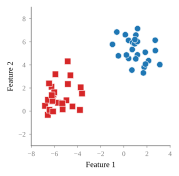

In [2]:
def toydata(N=50):
    y = torch.cat([torch.zeros(N // 2), torch.ones(N - N // 2)])
    c = torch.tensor([[-5.0, 1.0], [1.0, 5.0]])  # centers of the blobs
    s = torch.tensor([1.2, 1.0])  # std of the blobs
    X = c[y.long()] + s[y.long(), None] * torch.randn(N, 2)
    return X, y


torch.manual_seed(2)
N = 50  # number of data points
X, y = toydata(N=N)


def plot_data(ax, X, y):
    for cls, m, c in [(0, 's', 'tab:red'), (1, 'o', 'tab:blue')]:
        ax.scatter(
            *X[y == cls].T,
            marker=m,
            color=c,
            s=40,
            edgecolors='white',
            linewidths=0.5,
            label=cls,
        )


fig, ax = plt.subplots(figsize=(2.5, 2.5))
plot_data(ax, X, y)
ax.set(xlabel='Feature 1', ylabel='Feature 2', xlim=(-8, 4), ylim=(-3, 9));

Next, we set the prior precision and visualize the loss surface.

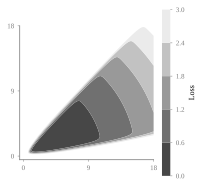

In [3]:
delta = 0.01  # this is the prior precision


def plot_loss(X, y, delta, xlim=(-0.5, 18), ylim=(-0.5, 18), ax=None):
    fig, ax = plt.subplots(figsize=(3, 3)) if ax is None else (ax.figure, ax)

    w = torch.linspace(-2, 30, 250, device=X.device, dtype=X.dtype)
    gw1, gw2 = torch.meshgrid(w, w, indexing='xy')
    W = torch.stack([gw1.ravel(), gw2.ravel()], 1)

    loss = (
        F.binary_cross_entropy_with_logits(W @ X.T, y[None].expand(W.shape[0], -1), reduction='none').sum(1)
        + 0.5 * delta * W.square().sum(1)
    ).reshape(250, 250)

    cmap = LinearSegmentedColormap.from_list('light_gray', [(0.2,) * 3, 'white'])

    cs = ax.contourf(gw1, gw2, loss.detach(), levels=torch.linspace(0, 3, 6), cmap=cmap)

    ticks = torch.linspace(0, 18, 3)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    ax.set(xlim=xlim, ylim=ylim, aspect='equal')
    ax.grid(False)
    fig.colorbar(cs, ax=ax, label='Loss').outline.set_visible(False)

    return fig, ax


fig, ax = plot_loss(X, y, delta)

Next, we train with IVON and SGD.

In [4]:
def make_model():
    m = torch.nn.Linear(2, 1, bias=False)
    with torch.no_grad():
        m.weight[:] = torch.tensor([3.0, 2.0])
    return m


# training loop
def train(model, opt, X, y, steps):
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, eta_min=0.0, T_max=steps)

    for _ in range(steps):
        ctx = opt.sampled_params(train=True) if isinstance(opt, (IVON, EVON)) else nullcontext()
        with ctx:
            opt.zero_grad()
            loss = F.binary_cross_entropy_with_logits(model(X).squeeze(-1), y)
            loss.backward()

        opt.step()
        sched.step()


model_ivon = make_model()
model_sgd = make_model()

opt_ivon = IVON(
    model_ivon.parameters(),
    lr=5.0,
    ess=N,  # since we target the Bayesian posterior
    weight_decay=delta / N,  # convert prior precision to weight decay
    hess_init=0.005,
    beta1=0.9,
    beta2=0.9995,
    rescale_lr=False
)

opt_sgd = torch.optim.SGD(
    model_sgd.parameters(),
    lr=5.0,
    weight_decay=delta / N,
)

train(model_ivon, opt_ivon, X, y, 10_000)
train(model_sgd, opt_sgd, X, y, 5_000)


Next, we train with EVON. It runs IVON in the eigenspace of the SOAP preconditioner, so its posterior covariance in weight space is not restricted to be diagonal and can capture correlations between the two weights.


In [5]:
model_evon = make_model()

opt_evon = EVON(
    model_evon.parameters(),
    lr=1.0,
    ess=N,  # since we target the Bayesian posterior
    weight_decay=delta / N,  # convert prior precision to weight decay
    hess_init=0.005,
    betas=(0.7, 0.9995),
    mc_samples=1,
    precondition_frequency=1,
    whiten_prec_grad=True,
)

train(model_evon, opt_evon, X, y, 10_000)


We visualize the solutions found by SGD and IVON. Since IVON finds a posterior distribution, we visualize it as an ellipse extending 1.5 standard deviations from the mean. We also use Laplace's method, to obtain uncertainty around the SGD solution.

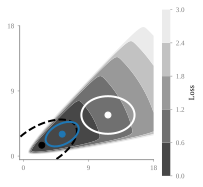

In [6]:
def loss_fn(w):
    logits = X @ w
    nll = F.binary_cross_entropy_with_logits(logits, y, reduction='sum')
    prior = 0.5 * delta * (w @ w)
    return nll + prior


def plot_cov_ellipse(ax, mu, Sigma, nstd=1.5, label=None, **kw):
    vals, vecs = torch.linalg.eigh(Sigma)
    angle = torch.rad2deg(torch.atan2(vecs[1, 0], vecs[0, 0])).item()
    ax.add_patch(Ellipse(mu, *(2 * nstd * vals.sqrt()), angle=angle, fill=False, **kw))
    ax.plot(*mu, 'o', label=label, color=kw.get('edgecolor', kw.get('color', 'r')))


# get Laplace covariance
map_sol = model_sgd.weight.detach().squeeze()
H = hessian(loss_fn)(map_sol)
Sigma = torch.linalg.inv(H)

with torch.no_grad():
    param = next(model_ivon.parameters())
    mean = param.squeeze().detach()
    hess = opt_ivon.state_dict()['param_groups'][0]['hess']
    covariance = torch.diag(1 / (N * hess + delta))

    # EVON posterior covariance from samples
    samples = []
    for _ in range(2000):
        with opt_evon.sampled_params(train=False):
            samples.append(model_evon.weight.detach().squeeze().clone())
    samples = torch.stack(samples)
    mean_evon = samples.mean(0)
    samples = samples - mean_evon
    cov_evon = samples.T @ samples / (len(samples) - 1)

    # plot results
    fig, ax = plot_loss(X, y, delta)
    plot_cov_ellipse(ax, map_sol, Sigma, color='k', linestyle='--', linewidth=2)
    plot_cov_ellipse(ax, mean, covariance, color='w', linewidth=2)
    plot_cov_ellipse(ax, mean_evon, cov_evon, color='tab:blue', linewidth=2)


We show the classifier at IVON's mean in black, and at the samples with the thin gray dashed lines.

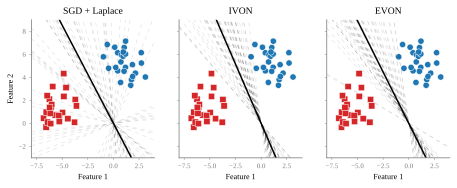

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(7.5, 2.5), sharex=True, sharey=True)

for ax in axs:
    plot_data(ax, X, y)
    ax.set(xlabel='Feature 1', ylabel='Feature 2', xlim=(-8, 4), ylim=(-3, 9))

xx = torch.linspace(*axs[0].get_xlim(), 100)

with torch.no_grad():
    w = model_sgd.weight.squeeze()
    axs[0].plot(xx, -(w[0] / w[1]) * xx, 'k-')
    axs[0].set_title('SGD + Laplace')

    w = model_ivon.weight.squeeze()
    axs[1].plot(xx, -(w[0] / w[1]) * xx, 'k-')
    axs[1].set_title('IVON')

    w = model_evon.weight.squeeze()
    axs[2].plot(xx, -(w[0] / w[1]) * xx, 'k-')
    axs[2].set_title('EVON')

    for ax in axs[1:]:
        ax.set_ylabel('')

    laplace = torch.distributions.MultivariateNormal(map_sol, precision_matrix=H)

    for w in laplace.sample((50,)):
        axs[0].plot(
            xx,
            -(w[0] / w[1]) * xx,
            linestyle=(0, (8, 8)),
            color='k',
            alpha=0.15,
            linewidth=0.5,
        )

    for _ in range(50):
        with opt_ivon.sampled_params(train=False):
            w = model_ivon.weight.squeeze()
            axs[1].plot(xx, -(w[0] / w[1]) * xx, linestyle=(0, (8, 8)), color='k', alpha=0.15, linewidth=0.5)

    for _ in range(50):
        with opt_evon.sampled_params(train=False):
            w = model_evon.weight.squeeze()
            axs[2].plot(xx, -(w[0] / w[1]) * xx, linestyle=(0, (8, 8)), color='k', alpha=0.15, linewidth=0.5)
